In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("csv_limpio.csv")

In [3]:
df.columns

Index(['ID_AERODROMO', 'ID_DEPARTAMENTO', 'ID_PROVINCIA', 'ID_DISTRITO',
       'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'NOMBRE', 'LABEL',
       'TIPO_AERODROMO', 'CODIGO_AERODROMO', 'CODIGO_OACI', 'ESCALA', 'ESTADO',
       'ADMINISTRADOR', 'JERARQUIA', 'TITULARIDAD', 'LATITUD', 'LONGITUD',
       'ES_CONCES', 'FECHA_CORTE'],
      dtype='object')

In [4]:
df.head(5)

,ID_AERODROMO,ID_DEPARTAMENTO,ID_PROVINCIA,ID_DISTRITO,DEPARTAMENTO,PROVINCIA,DISTRITO,NOMBRE,LABEL,TIPO_AERODROMO,...,CODIGO_OACI,ESCALA,ESTADO,ADMINISTRADOR,JERARQUIA,TITULARIDAD,LATITUD,LONGITUD,ES_CONCES,FECHA_CORTE
0,1,3,302,30201,APURÍMAC,ANDAHUAYLAS,ANDAHUAYLAS,ANDAHUAYLAS,AEROPUERTO ANDAHUAYLAS,Aeropuerto,...,SPHY,Nacional,Operativo,CORPAC S.A.,Nacional,Pública (Concesionada-No entregada),-13.708819,-73.351556,9,20221231
1,2,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,AERÓDROMO ANDOAS,Aeródromo,...,SPAS,Sin escala definida,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796108,-76.466597,-1,20221231
2,3,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,HELIPUERTO ANDOAS,Helipuerto,...,SPAN,Sin escala definida,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796111,-76.466625,-1,20221231
3,4,4,401,40103,AREQUIPA,AREQUIPA,CAYMA,AREQUIPA - INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,AEROPUERTO INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,Aeropuerto Internacional,...,SPQU,Internacional,Operativo,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-16.340611,-71.570792,1,20221231
4,5,25,2502,250201,UCAYALI,ATALAYA,RAYMONDI,ATALAYA,AERÓDROMO ATALAYA,Aeródromo,...,SPAY,Regional,Operativo,CORPAC S.A.,Regional,Pública,-10.728572,-73.765886,0,20221231


# Consulta 1 - Agrupamientos

## ¿Cuál es la cantidad de sedes aeroportuerias y la suma de sus códigos de provincia agrupadas por departamento, tipo de aeródromo y estado operativo?

In [5]:
c_1_1 = df.groupby(["DEPARTAMENTO", "TIPO_AERODROMO", "ESTADO"]).agg(
      {"ID_AERODROMO": "count",
      "ID_PROVINCIA": "sum"}
).reset_index()
c_1_1.columns = ['Departamento', 'Tipo', 'Estado', 'Cantidad_Sedes', 'Suma_ID_Prov']
c_1_1

,Departamento,Tipo,Estado,Cantidad_Sedes,Suma_ID_Prov
0,AMAZONAS,Aeropuerto,Operativo,2,207
1,AMAZONAS,Aeródromo,Operativo,2,208
2,AMAZONAS,Helipuerto,Operativo,1,107
3,APURÍMAC,Aeropuerto,Operativo,1,302
4,APURÍMAC,Helipuerto,Operativo,2,606
...,...,...,...,...,...
102,UCAYALI,Aeródromo,Operativo,9,22519
103,Ucayali,Aeropuerto Internacional,Operativo,2,5002
104,Ucayali,Aeródromo,Operativo,18,45038
105,ÁNCASH,Aeropuerto,Operativo,2,424


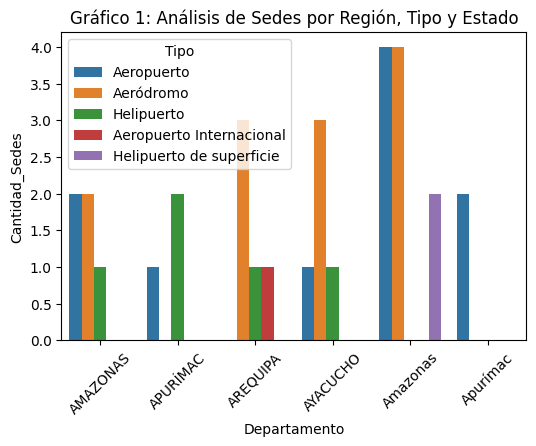

In [6]:
plt.figure(figsize=(6,4))
sns.barplot(data=c_1_1.head(15), x="Departamento", y="Cantidad_Sedes", hue="Tipo")
plt.title("Gráfico 1: Análisis de Sedes por Región, Tipo y Estado")
plt.xticks(rotation=45)
plt.show()

## ¿Cuál es el conteo de infraestructuras y la suma de sus códigos de distrito segmentados por la entidad administradora, su nivel de jerarquía y el tipo de titularidad?

In [7]:
c_1_2 = df.groupby(["ADMINISTRADOR", "JERARQUIA", "TITULARIDAD"]).agg({
    "ID_AERODROMO": "count",
    "ID_DISTRITO": "sum"
}).reset_index()
c_1_2.columns = ["Administrador","Jerarquia","Titularidad","Nro. Sedes","Sum_Id_Dist"]
c_1_2

,Administrador,Jerarquia,Titularidad,Nro. Sedes,Sum_Id_Dist
0,AERO LINK S.A.C.,Sin jerarquía definida,Privada,1,40307
1,AEROCLUB DE AVIACIÓN CIVIL DEL PERÚ,Sin jerarquía definida,Privada,1,200401
2,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),5,701522
3,AEROPUERTOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),12,1743545
4,AFE SERVICE S.A.C.,No aplica a privados,Privada,1,150125
...,...,...,...,...,...
195,SR. GUILLERMO PARODI MORALES,Sin jerarquía definida,Privada,1,50507
196,South América Mission Inc. Filial del Perú,No aplica a privados,Privada,1,250105
197,South América Mission Inc. Filial del Perú,No aplica privados,Privada,1,250105
198,Sr. Guillermo Parodi Morales,No aplica a privados,Privada,1,50507


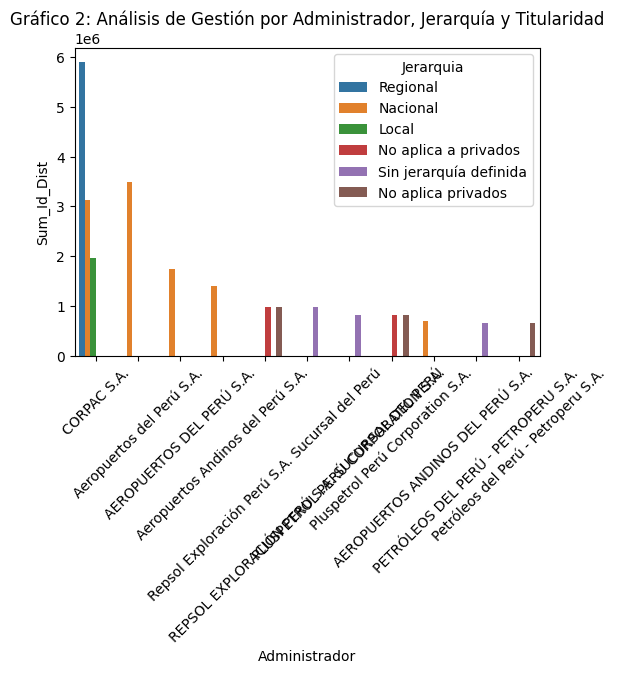

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=c_1_2.sort_values("Sum_Id_Dist", ascending=False).head(15),
            x="Administrador", y="Sum_Id_Dist", hue="Jerarquia")
plt.title("Gráfico 2: Análisis de Gestión por Administrador, Jerarquía y Titularidad")
plt.xticks(rotation=45)
plt.show()

# Consulta 2

## Generación de 3 nuevas columnas, extrayendo o transformando los datos de las columnas actuales, mencionando cuál será su futuro uso

### Columna 1 - Macroregiones

Permitirá comparar la densidad de aeródromos en la selva frente a la Costa y Sierra, sin la necesidad de comparar departamento por departamento

In [9]:
def asignar_macroregion(depart):
  selva = ['LORETO', 'UCAYALI', 'AMAZONAS', 'MADRE DE DIOS', 'SAN MARTÍN']
  sierra = ['CUSCO', 'PUNO', 'APURÍMAC', 'HUÁNUCO', 'PASCO', 'JUNÍN', 'AYACUCHO', 'HUANCAVELICA']
  if depart in selva: return 'SELVA'
  elif depart in sierra: return 'SIERRA'
  else: return 'COSTA'

In [10]:
df["MACROREGION"] = df["DEPARTAMENTO"].apply(asignar_macroregion)

In [11]:
df.head(5)

,ID_AERODROMO,ID_DEPARTAMENTO,ID_PROVINCIA,ID_DISTRITO,DEPARTAMENTO,PROVINCIA,DISTRITO,NOMBRE,LABEL,TIPO_AERODROMO,...,ESCALA,ESTADO,ADMINISTRADOR,JERARQUIA,TITULARIDAD,LATITUD,LONGITUD,ES_CONCES,FECHA_CORTE,MACROREGION
0,1,3,302,30201,APURÍMAC,ANDAHUAYLAS,ANDAHUAYLAS,ANDAHUAYLAS,AEROPUERTO ANDAHUAYLAS,Aeropuerto,...,Nacional,Operativo,CORPAC S.A.,Nacional,Pública (Concesionada-No entregada),-13.708819,-73.351556,9,20221231,SIERRA
1,2,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,AERÓDROMO ANDOAS,Aeródromo,...,Sin escala definida,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796108,-76.466597,-1,20221231,SELVA
2,3,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,HELIPUERTO ANDOAS,Helipuerto,...,Sin escala definida,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796111,-76.466625,-1,20221231,SELVA
3,4,4,401,40103,AREQUIPA,AREQUIPA,CAYMA,AREQUIPA - INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,AEROPUERTO INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,Aeropuerto Internacional,...,Internacional,Operativo,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-16.340611,-71.570792,1,20221231,COSTA
4,5,25,2502,250201,UCAYALI,ATALAYA,RAYMONDI,ATALAYA,AERÓDROMO ATALAYA,Aeródromo,...,Regional,Operativo,CORPAC S.A.,Regional,Pública,-10.728572,-73.765886,0,20221231,SELVA


### Columna 2 - SITUACION LEGAL

Se usará para hacerlo en gráficos circulares y barras apiladas en la gestión de la infraestructura, esto permitiá que los aeropuertos no se mezclen erroneamente como el aeropuerto de andahuaylas que aún no ha sido entregado, y permite un análisis de la seguridad jurídica de la infraestructura

In [12]:
def categorizar_conse(conse):
  if conse==1:
    return "Concesionada"
  elif conse==9:
    return "Concesionada (Pendiente de Entrega)"
  elif conse==-1:
    return "Privada (No aplica)"
  else:
    return "Pública (No Concesionada)"

In [13]:
df["SITUACION_LEGAL"] = df["ES_CONCES"].apply(categorizar_conse)

In [14]:
df.head(10)

,ID_AERODROMO,ID_DEPARTAMENTO,ID_PROVINCIA,ID_DISTRITO,DEPARTAMENTO,PROVINCIA,DISTRITO,NOMBRE,LABEL,TIPO_AERODROMO,...,ESTADO,ADMINISTRADOR,JERARQUIA,TITULARIDAD,LATITUD,LONGITUD,ES_CONCES,FECHA_CORTE,MACROREGION,SITUACION_LEGAL
0,1,3,302,30201,APURÍMAC,ANDAHUAYLAS,ANDAHUAYLAS,ANDAHUAYLAS,AEROPUERTO ANDAHUAYLAS,Aeropuerto,...,Operativo,CORPAC S.A.,Nacional,Pública (Concesionada-No entregada),-13.708819,-73.351556,9,20221231,SIERRA,Concesionada (Pendiente de Entrega)
1,2,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,AERÓDROMO ANDOAS,Aeródromo,...,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796108,-76.466597,-1,20221231,SELVA,Privada (No aplica)
2,3,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,HELIPUERTO ANDOAS,Helipuerto,...,Operativo,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796111,-76.466625,-1,20221231,SELVA,Privada (No aplica)
3,4,4,401,40103,AREQUIPA,AREQUIPA,CAYMA,AREQUIPA - INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,AEROPUERTO INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,Aeropuerto Internacional,...,Operativo,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-16.340611,-71.570792,1,20221231,COSTA,Concesionada
4,5,25,2502,250201,UCAYALI,ATALAYA,RAYMONDI,ATALAYA,AERÓDROMO ATALAYA,Aeródromo,...,Operativo,CORPAC S.A.,Regional,Pública,-10.728572,-73.765886,0,20221231,SELVA,Pública (No Concesionada)
5,6,5,501,50116,AYACUCHO,HUAMANGA,ANDRÉS AVELINO CÁCERES,AYACUCHO - CRNL. FAP ALFREDO MENDIVIL,AEROPUERTO CRNL. FAP ALFREDO MENDIVIL,Aeropuerto,...,Operativo,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-13.154836,-74.204417,1,20221231,SIERRA,Concesionada
6,7,16,1602,160205,LORETO,ALTO AMAZONAS,JEBEROS,BELLAVISTA,AERÓDROMO BELLAVISTA,Aeródromo,...,Operativo,COMUNIDAD DE BELLAVISTA,Sin jerarquía definida,Pública,-5.283333,-76.383333,0,20221231,SELVA,Pública (No Concesionada)
7,8,16,1605,160506,LORETO,REQUENA,PIUINAHUA,BRETAÑA 1,HELIPUERTO BRETAÑA 1,Helipuerto,...,Operativo,PETROTAL PERÚ S.R.L.,Sin jerarquía definida,Privada,-5.245690,-74.328958,-1,20221231,SELVA,Privada (No aplica)
8,9,25,2502,250204,UCAYALI,ATALAYA,YURUA,BREU,AERÓDROMO BREU,Aeródromo,...,Operativo,CORPAC S.A.,Local,Pública,-9.533792,-72.757153,0,20221231,SELVA,Pública (No Concesionada)
9,10,16,1605,160509,LORETO,REQUENA,TAPICHE,BUNCUYO,AERÓDROMO BUNCUYO,Aeródromo,...,Operativo,COMUNIDAD DE BUNCUYO,Sin jerarquía definida,Pública,-6.516667,-74.583333,0,20221231,SELVA,Pública (No Concesionada)


### Columna 3 - AÑO

Servirá como eje X en los Gráficos de Lineas y Tendencias Acumulativas para así visualizar la evolución del inventario de aeródromos a los largo de los años (2022-2024)

In [15]:
df["ANIO_CORTE"] = df["FECHA_CORTE"].astype(str).str[:4]

In [16]:
df.head(10)

,ID_AERODROMO,ID_DEPARTAMENTO,ID_PROVINCIA,ID_DISTRITO,DEPARTAMENTO,PROVINCIA,DISTRITO,NOMBRE,LABEL,TIPO_AERODROMO,...,ADMINISTRADOR,JERARQUIA,TITULARIDAD,LATITUD,LONGITUD,ES_CONCES,FECHA_CORTE,MACROREGION,SITUACION_LEGAL,ANIO_CORTE
0,1,3,302,30201,APURÍMAC,ANDAHUAYLAS,ANDAHUAYLAS,ANDAHUAYLAS,AEROPUERTO ANDAHUAYLAS,Aeropuerto,...,CORPAC S.A.,Nacional,Pública (Concesionada-No entregada),-13.708819,-73.351556,9,20221231,SIERRA,Concesionada (Pendiente de Entrega),2022
1,2,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,AERÓDROMO ANDOAS,Aeródromo,...,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796108,-76.466597,-1,20221231,SELVA,Privada (No aplica),2022
2,3,16,1607,160706,LORETO,DATEM DEL MARAÑÓN,ANDOAS,ANDOAS,HELIPUERTO ANDOAS,Helipuerto,...,PACIFIC STRATUS ENERGY DEL PERÚ S.A.,Sin jerarquía definida,Privada,-2.796111,-76.466625,-1,20221231,SELVA,Privada (No aplica),2022
3,4,4,401,40103,AREQUIPA,AREQUIPA,CAYMA,AREQUIPA - INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,AEROPUERTO INTERNACIONAL ALFREDO RODRÍGUEZ BALLON,Aeropuerto Internacional,...,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-16.340611,-71.570792,1,20221231,COSTA,Concesionada,2022
4,5,25,2502,250201,UCAYALI,ATALAYA,RAYMONDI,ATALAYA,AERÓDROMO ATALAYA,Aeródromo,...,CORPAC S.A.,Regional,Pública,-10.728572,-73.765886,0,20221231,SELVA,Pública (No Concesionada),2022
5,6,5,501,50116,AYACUCHO,HUAMANGA,ANDRÉS AVELINO CÁCERES,AYACUCHO - CRNL. FAP ALFREDO MENDIVIL,AEROPUERTO CRNL. FAP ALFREDO MENDIVIL,Aeropuerto,...,AEROPUERTOS ANDINOS DEL PERÚ S.A.,Nacional,Pública (Concesionada),-13.154836,-74.204417,1,20221231,SIERRA,Concesionada,2022
6,7,16,1602,160205,LORETO,ALTO AMAZONAS,JEBEROS,BELLAVISTA,AERÓDROMO BELLAVISTA,Aeródromo,...,COMUNIDAD DE BELLAVISTA,Sin jerarquía definida,Pública,-5.283333,-76.383333,0,20221231,SELVA,Pública (No Concesionada),2022
7,8,16,1605,160506,LORETO,REQUENA,PIUINAHUA,BRETAÑA 1,HELIPUERTO BRETAÑA 1,Helipuerto,...,PETROTAL PERÚ S.R.L.,Sin jerarquía definida,Privada,-5.245690,-74.328958,-1,20221231,SELVA,Privada (No aplica),2022
8,9,25,2502,250204,UCAYALI,ATALAYA,YURUA,BREU,AERÓDROMO BREU,Aeródromo,...,CORPAC S.A.,Local,Pública,-9.533792,-72.757153,0,20221231,SELVA,Pública (No Concesionada),2022
9,10,16,1605,160509,LORETO,REQUENA,TAPICHE,BUNCUYO,AERÓDROMO BUNCUYO,Aeródromo,...,COMUNIDAD DE BUNCUYO,Sin jerarquía definida,Pública,-6.516667,-74.583333,0,20221231,SELVA,Pública (No Concesionada),2022


# Consulta 3

## Implementación de matriz de correlación de al menos 6 columnas usando seaborn e interpretar

In [17]:
df.columns

Index(['ID_AERODROMO', 'ID_DEPARTAMENTO', 'ID_PROVINCIA', 'ID_DISTRITO',
       'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'NOMBRE', 'LABEL',
       'TIPO_AERODROMO', 'CODIGO_AERODROMO', 'CODIGO_OACI', 'ESCALA', 'ESTADO',
       'ADMINISTRADOR', 'JERARQUIA', 'TITULARIDAD', 'LATITUD', 'LONGITUD',
       'ES_CONCES', 'FECHA_CORTE', 'MACROREGION', 'SITUACION_LEGAL',
       'ANIO_CORTE'],
      dtype='object')

In [18]:
df.dtypes

,0
ID_AERODROMO,int64
ID_DEPARTAMENTO,int64
ID_PROVINCIA,int64
ID_DISTRITO,int64
DEPARTAMENTO,object
PROVINCIA,object
DISTRITO,object
NOMBRE,object
LABEL,object
TIPO_AERODROMO,object


### ¿Existe una relación estadística entre la ubicación geográfica (Latitud/Longitud), la codificación política (IDs de Departamento/Provincia) y el estado de concesión de la infraestructura?

In [19]:
# Usaremos las columnas que son de campo numérico
use_columns = [
    'ID_DEPARTAMENTO',
    'ID_PROVINCIA',
    'ID_DISTRITO',
    'LATITUD',
    'LONGITUD',
    'ES_CONCES'
]

df_corr = df[use_columns].corr()

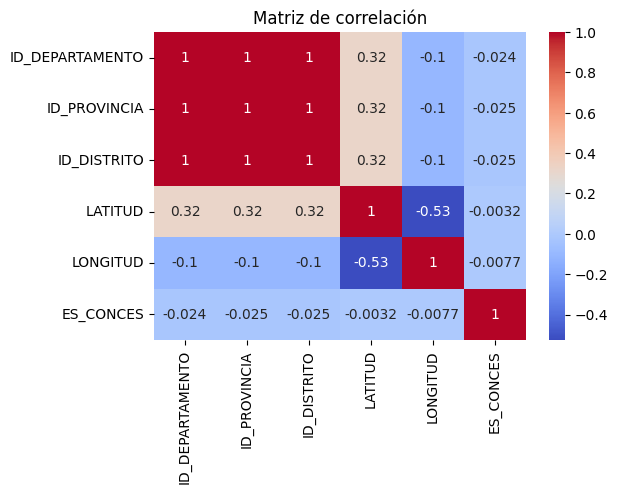

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

# Consulta 4

### Grafico 1 - ¿Cómo se distribuyen los diferentes tipos de Infraestructura (Aeródromo, Aeropuerto, Helipuerto) en cada Macroregión según su estado operativo?

In [21]:
c_4_1 = df.groupby(["MACROREGION", "TIPO_AERODROMO", "ESTADO"]).size().reset_index(name = "CONTEO")
c_4_1

,MACROREGION,TIPO_AERODROMO,ESTADO,CONTEO
0,COSTA,Aeropuerto,Operativo,45
1,COSTA,Aeropuerto Internacional,Operativo,29
2,COSTA,Aeródromo,Operativo,151
3,COSTA,Helipuerto,Operativo,17
4,COSTA,Helipuerto Elevado,Operativo,12
5,COSTA,Helipuerto de superficie,Operativo,95
6,SELVA,Aeropuerto,Operativo,7
7,SELVA,Aeropuerto Internacional,Operativo,2
8,SELVA,Aeródromo,Operativo,28
9,SELVA,Helipuerto,Operativo,11


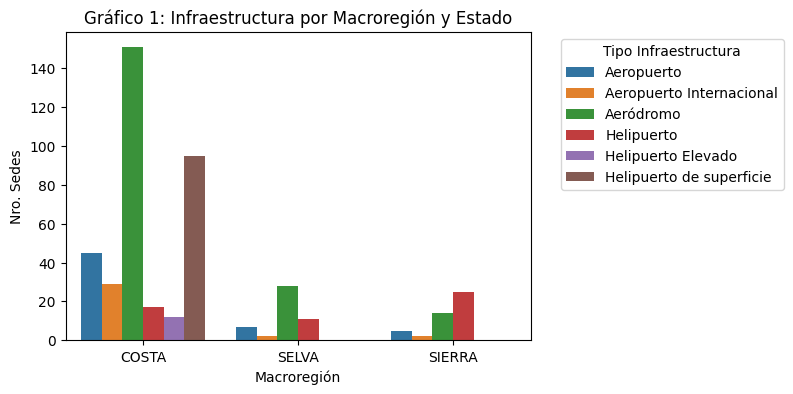

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(data=c_4_1, x="MACROREGION", y="CONTEO", hue="TIPO_AERODROMO")
plt.title("Gráfico 1: Infraestructura por Macroregión y Estado")
plt.xlabel("Macroregión")
plt.ylabel("Nro. Sedes")
plt.legend(title="Tipo Infraestructura", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Gráfico 2 - Cuál es la cantidad de sedes administradas por CORPAC u otros entes, según su jerarquía (Nacional/Regional) y su situación legal (Concesionada/Privada)?

In [23]:
c_4_2 = df["ADMINISTRADOR"].value_counts().nlargest(5).index
c_4_2 = df[df["ADMINISTRADOR"].isin(c_4_2)]
c_4_2=c_4_2.groupby(["ADMINISTRADOR", "JERARQUIA", "SITUACION_LEGAL"]).size().reset_index(name = "TOTAL")
c_4_2

,ADMINISTRADOR,JERARQUIA,SITUACION_LEGAL,TOTAL
0,AEROPUERTOS DEL PERÚ S.A.,Nacional,Concesionada,12
1,Aeropuertos del Perú S.A.,Nacional,Concesionada,24
2,CORPAC S.A.,Local,Pública (No Concesionada),15
3,CORPAC S.A.,Nacional,Concesionada (Pendiente de Entrega),3
4,CORPAC S.A.,Nacional,Pública (No Concesionada),27
5,CORPAC S.A.,Regional,Pública (No Concesionada),39
6,CORPAC S.A.,Sin jerarquía,Pública (No Concesionada),1
7,CORPAC S.A.,Sin jerarquía definida,Pública (No Concesionada),3
8,Pluspetrol Perú Corporation S.A.,No aplica a privados,Privada (No aplica),10
9,Pluspetrol Perú Corporation S.A.,No aplica privados,Privada (No aplica),10


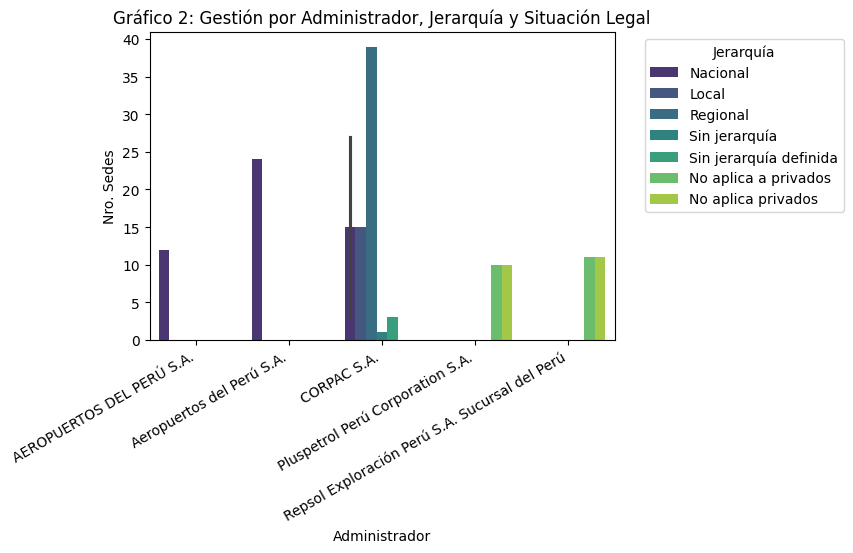

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(data=c_4_2, x="ADMINISTRADOR", y="TOTAL", hue="JERARQUIA", palette="viridis")
plt.title("Gráfico 2: Gestión por Administrador, Jerarquía y Situación Legal")
plt.xlabel("Administrador")
plt.ylabel("Nro. Sedes")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Jerarquía", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Consulta 5

### Gráfico 1: ¿Cómo ha evolucionado la cantidad de registros de infraestructura aeroportuaria en las tres Macroregiones (Costa, Sierra, Selva) a través de los años de corte?

In [25]:
c_5_1 = df.groupby(["ANIO_CORTE", "MACROREGION", "TIPO_AERODROMO"]).size().reset_index(name="CONTEO")
c_5_1["ANIO_CORTE"] = c_5_1["ANIO_CORTE"].astype(str)

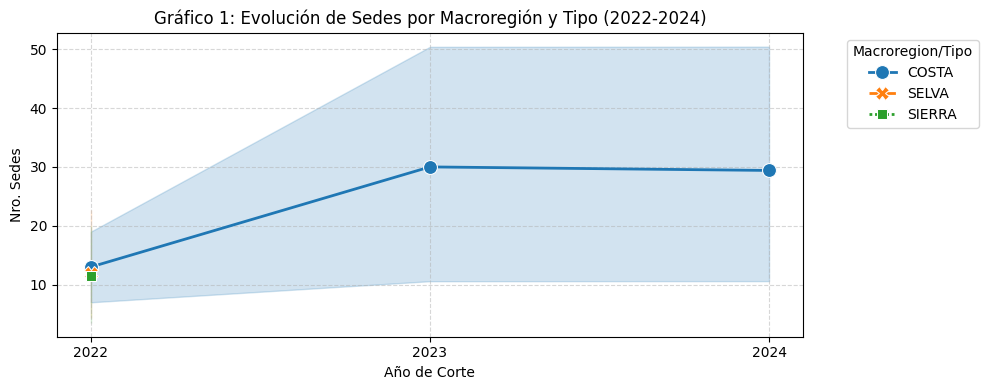

In [26]:
plt.figure(figsize=(10,4))
sns.lineplot(data=c_5_1, x="ANIO_CORTE", y="CONTEO", hue="MACROREGION", style="MACROREGION", markers=True, markersize=10, linewidth=2)
plt.title("Gráfico 1: Evolución de Sedes por Macroregión y Tipo (2022-2024)")
plt.xlabel("Año de Corte")
plt.ylabel("Nro. Sedes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Macroregion/Tipo", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

### Gráfico 2: ¿Cuál es la tendencia anual del número de infraestructuras según su Situación Legal (Concesionada, Privada, etc) y su nivel de Jerarquía?

In [27]:
c_5_2 = df.groupby(["ANIO_CORTE", "SITUACION_LEGAL", "JERARQUIA"]).size().reset_index(name="TOTAL")
c_5_2["ANIO_CORTE"]=c_5_2["ANIO_CORTE"].astype(str)

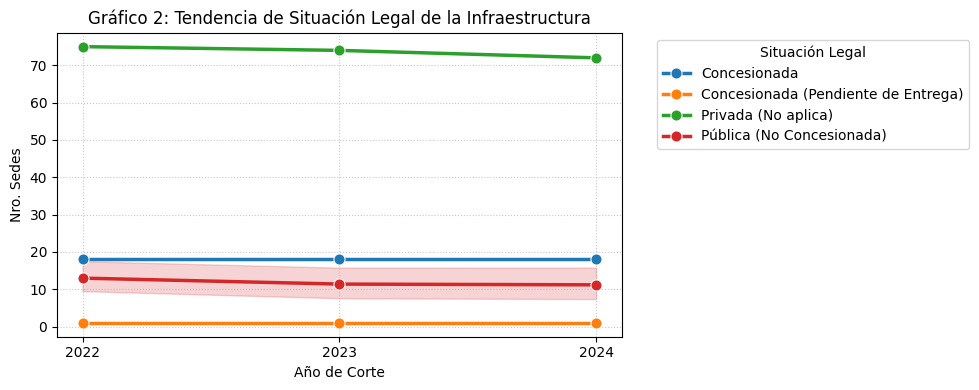

In [28]:
plt.figure(figsize=(10,4))
sns.lineplot(data=c_5_2, x="ANIO_CORTE", y="TOTAL", hue="SITUACION_LEGAL", marker="o", markersize=8, linewidth=2.5)
plt.title("Gráfico 2: Tendencia de Situación Legal de la Infraestructura")
plt.xlabel("Año de Corte")
plt.ylabel("Nro. Sedes")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(title="Situación Legal", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# Consulta 6

### ¿Cómo ha crecido el registro total acumulado de infraestructuras en cada Macroregion (Costa, Sierra, Selva) a través de los años?

In [29]:
c_6_1=df.groupby(["ANIO_CORTE", "MACROREGION"]).size().reset_index(name="CONTEO")
c_6_1["ACUMULADO"]=c_6_1.groupby("MACROREGION")["CONTEO"].cumsum()
c_6_1

,ANIO_CORTE,MACROREGION,CONTEO,ACUMULADO
0,2022,COSTA,52,52
1,2022,SELVA,48,48
2,2022,SIERRA,46,46
3,2023,COSTA,150,202
4,2024,COSTA,147,349


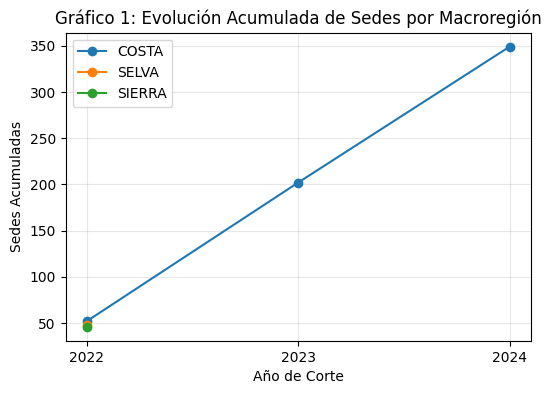

In [30]:
plt.figure(figsize=(6,4))
for region in c_6_1["MACROREGION"].unique():
    datos_region = c_6_1[c_6_1["MACROREGION"] == region]
    plt.plot(datos_region["ANIO_CORTE"].astype(str), datos_region["ACUMULADO"], marker='o', label=region)

plt.title("Gráfico 1: Evolución Acumulada de Sedes por Macroregión")
plt.xlabel("Año de Corte")
plt.ylabel("Sedes Acumuladas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### ¿Cuál es el crecimiento acumulativo de la infraestructura según su Situación Legal (Privada, Concesionada, Pública) en los periodos reportados?

In [31]:
c_6_2 = df.groupby(['ANIO_CORTE', 'SITUACION_LEGAL']).size().reset_index(name='CONTEO')

c_6_2['ACUMULADO'] = c_6_2.groupby('SITUACION_LEGAL')['CONTEO'].cumsum()

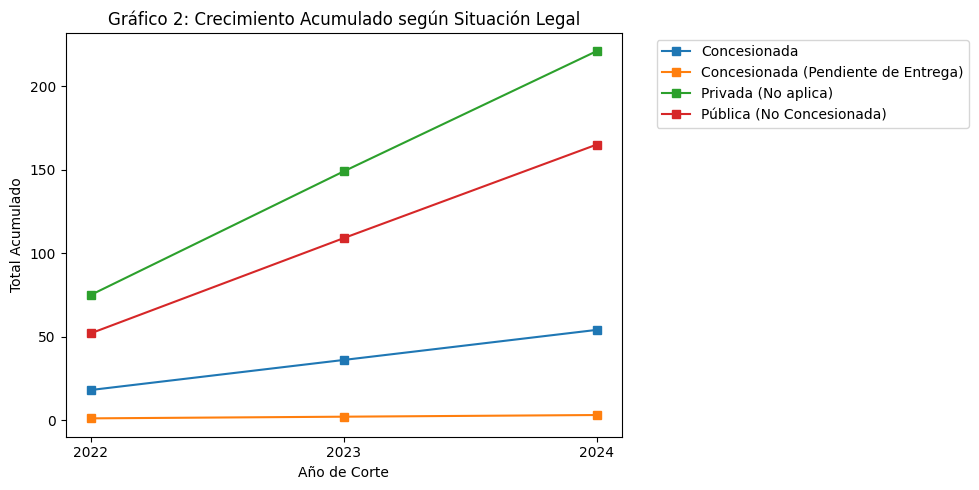

In [32]:
plt.figure(figsize=(10, 5))
for situacion in c_6_2["SITUACION_LEGAL"].unique():
    datos_sit = c_6_2[c_6_2["SITUACION_LEGAL"] == situacion]
    plt.plot(datos_sit["ANIO_CORTE"].astype(str), datos_sit["ACUMULADO"], marker='s', label=situacion)

plt.title("Gráfico 2: Crecimiento Acumulado según Situación Legal")
plt.xlabel("Año de Corte")
plt.ylabel("Total Acumulado")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### ¿Cómo se acumula el total de activos registrados en el país diferenciado por Tipo (Aeródromo vs Aeropuerto)?

In [33]:
c_6_3 = df.groupby(['ANIO_CORTE', 'TIPO_AERODROMO']).size().reset_index(name='CONTEO')
c_6_3['ACUMULADO'] = c_6_3.groupby('TIPO_AERODROMO')['CONTEO'].cumsum()
c_6_3

,ANIO_CORTE,TIPO_AERODROMO,CONTEO,ACUMULADO
0,2022,Aeropuerto,19,19
1,2022,Aeropuerto Internacional,11,11
2,2022,Aeródromo,63,63
3,2022,Helipuerto,53,53
4,2023,Aeropuerto,19,38
5,2023,Aeropuerto Internacional,11,22
6,2023,Aeródromo,66,129
7,2023,Helipuerto Elevado,6,6
8,2023,Helipuerto de superficie,48,48
9,2024,Aeropuerto,19,57


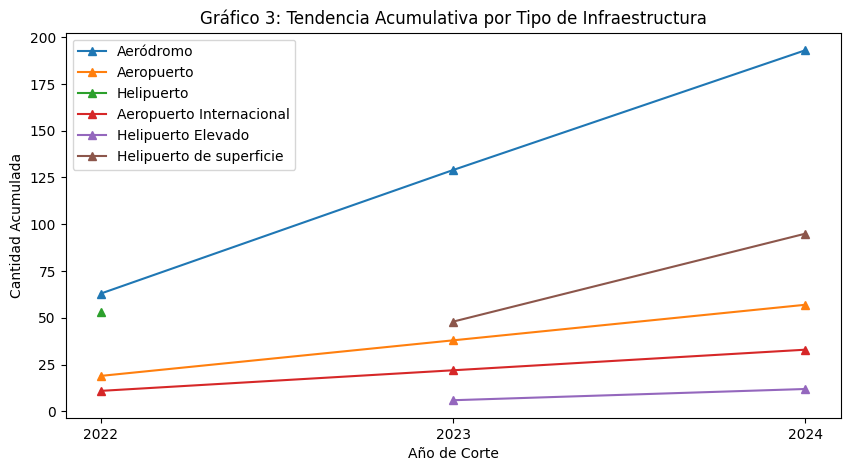

In [34]:
plt.figure(figsize=(10, 5))
tipos_principales = ['Aeródromo', 'Aeropuerto', 'Helipuerto', "Aeropuerto Internacional", "Helipuerto Elevado", "Helipuerto de superficie"]
for tipo in tipos_principales:
    if tipo in c_6_3["TIPO_AERODROMO"].unique():
        datos_tipo = c_6_3[c_6_3["TIPO_AERODROMO"] == tipo]
        plt.plot(datos_tipo["ANIO_CORTE"].astype(str), datos_tipo["ACUMULADO"], marker='^', label=tipo)

plt.title("Gráfico 3: Tendencia Acumulativa por Tipo de Infraestructura")
plt.xlabel("Año de Corte")
plt.ylabel("Cantidad Acumulada")
plt.legend()
plt.show()

# Consulta 7

### Gráfico 1: ¿Cuál es la proporción de los diferentes tipos de infraestructura (Aeródromos, Helipuertos, etc) especificamente en la Selva?

In [35]:
c_7_1 = df[df["MACROREGION"] == "SELVA"].groupby("TIPO_AERODROMO").size()

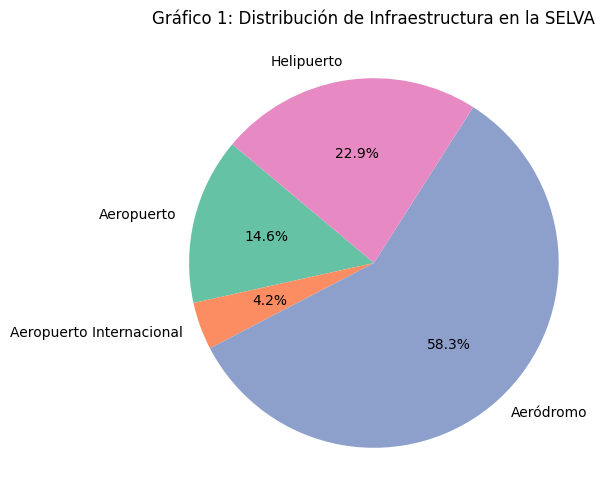

In [36]:
plt.figure(figsize=(8, 6))
etiquetas = c_7_1.index

plt.pie(c_7_1, labels=etiquetas, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("Set2"))
plt.title("Gráfico 1: Distribución de Infraestructura en la SELVA")
plt.show()

### ¿Cómo se divide el nivel de importancia (Jerarquía) de las sedes ubicadas únicamente en la costa?

In [37]:
c_7_2 = df[df["MACROREGION"] == "COSTA"].groupby("JERARQUIA").size()

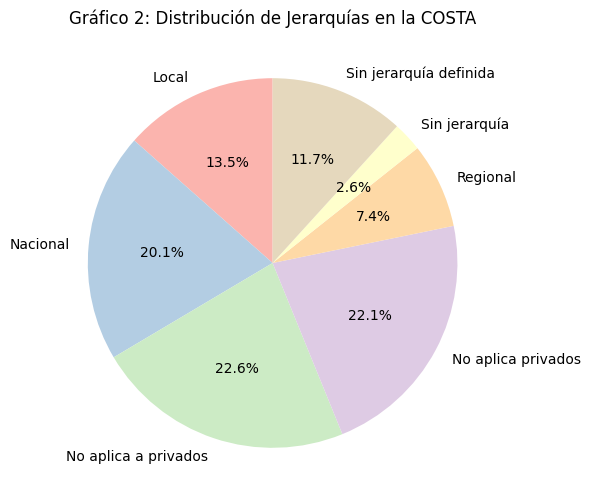

In [38]:
plt.figure(figsize=(8, 6))
etiquetas_jer = c_7_2.index

plt.pie(c_7_2, labels=etiquetas_jer, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Pastel1"))
plt.title("Gráfico 2: Distribución de Jerarquías en la COSTA")
plt.show()

# Guardar nuevo csv

In [39]:
df.to_csv("csv_nuevo.csv", index=False, encoding="utf-8-sig")